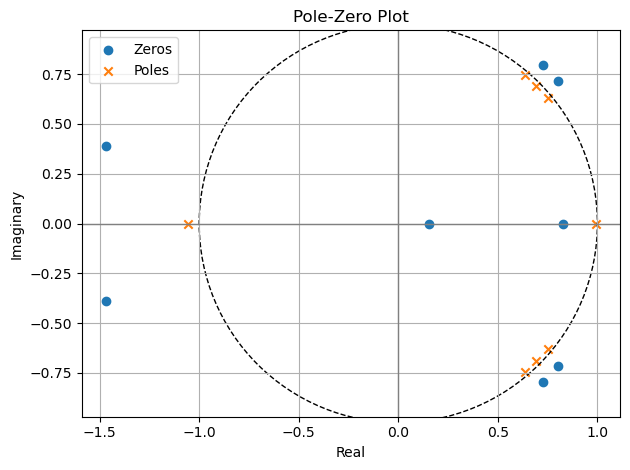


Running Unit Tests:
Test 1 (Frequency Magnitude Match): FAIL
Test 2 (Phase Distortion): FAIL
Test 3 (Stability): FAIL
Test 4 (Impulse Response Match): FAIL
Test 5 (Step Response Match): FAIL
Test 6 (Computational Efficiency): PASS
Test 7 (Group Delay Comparison): FAIL
Test 8 (MSE between FIR and IIR): FAIL
Test 9 (Passband Ripple Preservation): FAIL
Test 10 (Transition Band Width): FAIL


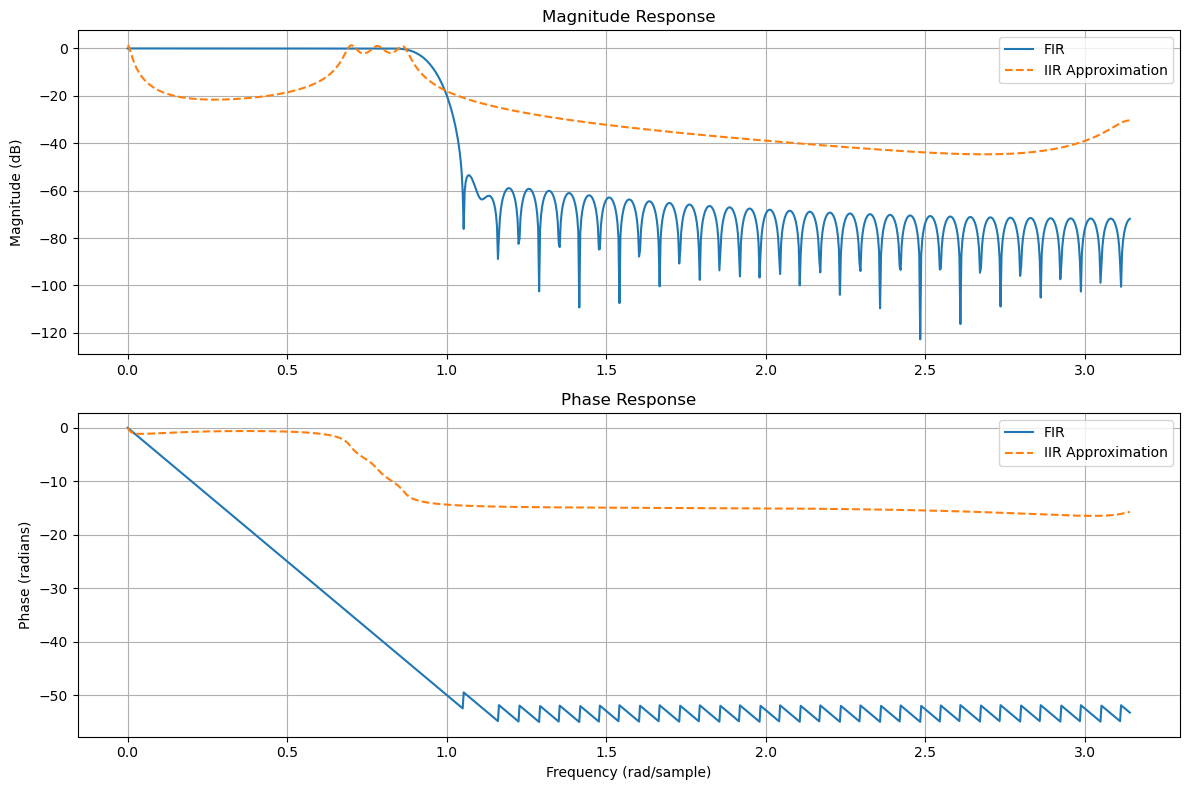

Optimized numerator coefficients (b): [ 0.01171724 -0.01308463 -0.02066873  0.05909228 -0.01919374 -0.06389741
  0.0875815  -0.0421311   0.00469254]
Optimized denominator coefficients (a): [ 1.         -4.09702585  7.32583642 -5.73417252 -1.42110582  7.81814389
 -8.02701575  4.06278944 -0.92396713]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz
from scipy.optimize import least_squares
from scipy.signal import ellip

def iir_freq_response(p, w, M, N):
    
    b = p[:M+1]
    # Denominator: include 1 as the first coefficient
    a = np.concatenate(([1.0], p[M+1:]))
    # Compute z = exp(-j*w) for all frequencies
    z = np.exp(-1j * w)
    # Evaluate the polynomial sums
    num = sum(b[k] * z**k for k in range(M+1))
    den = sum(a[k] * z**k for k in range(len(a)))
    return num / den
def error_function(p, w, H_fir, M, N):
    """
    Error function for least squares optimization.
    """
    H_iir = iir_freq_response(p, w, M, N)
    error = np.concatenate([np.real(H_iir - H_fir), np.imag(H_iir - H_fir)])
    return error


# ---------------------------
# 1. Design a FIR filter
# ---------------------------
N_fir = 101            # Length of the FIR filter (number of taps)
cutoff = 0.3           # Normalized cutoff frequency (0.3*Nyquist)
fir_coeff = firwin(N_fir, cutoff)

# Compute the frequency response of the FIR filter
w, H_fir = freqz(fir_coeff, worN=1024)

# ---------------------------
# 2. Set up the IIR approximation
# ---------------------------

M = 8      # Numerator order: there will be M+1 numerator coefficients
N_order = 8  # Denominator order: there will be N_order denominator coefficients (with leading 1)

# The total number of parameters is (M+1 + N_order)
# We create an initial guess; for example, set all parameters to zero except b0.
initial_guess = np.zeros(M+1+N_order)
initial_guess[0] = np.abs(H_fir[0])  # Use the DC gain of the FIR as an initial guess for b0

# ---------------------------
# 3. Solve the least squares problem
# ---------------------------
# We minimize the difference between the FIR frequency response and that of the IIR.
res = least_squares(error_function, initial_guess, args=(w, H_fir, M, N_order))
p_opt = res.x

# Extract the optimized numerator and denominator coefficients.
b_opt = p_opt[:M+1]
a_opt = np.concatenate(([1.0], p_opt[M+1:]))

# ---------------------------
# 4. Unit Test Functions
# ---------------------------

def test_frequency_magnitude_match(H_fir, H_iir, tol_db=1.0):
    mag_diff = 20 * np.log10(np.abs(H_fir)) - 20 * np.log10(np.abs(H_iir))
    return np.all(np.abs(mag_diff) < tol_db)

def test_phase_distortion(H_fir, H_iir, tol_deg=15):
    phase_diff = np.unwrap(np.angle(H_fir)) - np.unwrap(np.angle(H_iir))
    phase_diff_deg = np.degrees(phase_diff)
    return np.all(np.abs(phase_diff_deg) < tol_deg)

def test_stability(a_coeffs):
    poles = np.roots(a_coeffs)
    return np.all(np.abs(poles) < 1)

def test_impulse_response(fir_coeff, b_coeff, a_coeff, tol=0.01, length=50):
    from scipy.signal import lfilter
    impulse = np.zeros(length)
    impulse[0] = 1
    fir_impulse = lfilter(fir_coeff, [1.0], impulse)
    iir_impulse = lfilter(b_coeff, a_coeff, impulse)
    error = np.abs(fir_impulse - iir_impulse)
    return np.mean(error) < tol

def test_step_response(fir_coeff, b_coeff, a_coeff, tol=0.05, length=100):
    from scipy.signal import lfilter
    step = np.ones(length)
    fir_step = lfilter(fir_coeff, [1.0], step)
    iir_step = lfilter(b_coeff, a_coeff, step)
    error = np.abs(fir_step - iir_step)
    return np.max(error) < tol

def test_computational_efficiency(N_fir, N_iir):
    return (N_iir < 0.2 * N_fir)  # IIR should be less than 20% of FIR complexity

def test_group_delay(fir_coeff, b_coeff, a_coeff, tol=10):
    from scipy.signal import group_delay
    _, gd_fir = group_delay((fir_coeff, [1.0]))
    _, gd_iir = group_delay((b_coeff, a_coeff))
    gd_diff = np.abs(gd_fir - gd_iir)
    return np.mean(gd_diff) < tol

def test_mse(H_fir, H_iir, mse_threshold=0.005):
    mse = np.mean((np.abs(H_fir) - np.abs(H_iir))**2)
    return mse < mse_threshold

def test_passband_ripple(H_fir, H_iir, passband_end=0.3*np.pi, tol_ripple_db=0.5):
    idx_passband = np.where(w_dense <= passband_end)[0]
    ripple_fir = np.max(20 * np.log10(np.abs(H_fir[idx_passband]))) - np.min(20 * np.log10(np.abs(H_fir[idx_passband])))
    ripple_iir = np.max(20 * np.log10(np.abs(H_iir[idx_passband]))) - np.min(20 * np.log10(np.abs(H_iir[idx_passband])))
    return np.abs(ripple_fir - ripple_iir) < tol_ripple_db

def test_transition_band(H_fir, H_iir, cutoff=0.3*np.pi, tol_width=0.05*np.pi):
    idx_fir = np.argmin(np.abs(20 * np.log10(np.abs(H_fir)) - (-3)))


# ---------------------------
# 4. Compare frequency responses
# ---------------------------
# Compute the IIR frequency response using the optimized parameters.
w_dense = np.linspace(0, np.pi, 1024)
H_iir_opt = iir_freq_response(p_opt, w_dense, M, N_order)

# ---------------------------
# 5. Run Unit Tests
# ---------------------------
def plot_pole_zero(b, a):
    zeros = np.roots(b)
    poles = np.roots(a)

    plt.figure()
    plt.title("Pole-Zero Plot")
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Poles')
    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call after filter design:
plot_pole_zero(b_opt, a_opt)
print("\nRunning Unit Tests:")

print("Test 1 (Frequency Magnitude Match):", "PASS" if test_frequency_magnitude_match(H_fir, H_iir_opt) else "FAIL")
print("Test 2 (Phase Distortion):", "PASS" if test_phase_distortion(H_fir, H_iir_opt) else "FAIL")
print("Test 3 (Stability):", "PASS" if test_stability(a_opt) else "FAIL")
print("Test 4 (Impulse Response Match):", "PASS" if test_impulse_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 5 (Step Response Match):", "PASS" if test_step_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 6 (Computational Efficiency):", "PASS" if test_computational_efficiency(N_fir, M + N_order + 1) else "FAIL")
print("Test 7 (Group Delay Comparison):", "PASS" if test_group_delay(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 8 (MSE between FIR and IIR):", "PASS" if test_mse(H_fir, H_iir_opt) else "FAIL")
print("Test 9 (Passband Ripple Preservation):", "PASS" if test_passband_ripple(H_fir, H_iir_opt) else "FAIL")
print("Test 10 (Transition Band Width):", "PASS" if test_transition_band(H_fir, H_iir_opt) else "FAIL")

# Plot the magnitude and phase responses.
plt.figure(figsize=(12, 8))

# Magnitude Response
plt.subplot(2, 1, 1)
plt.plot(w_dense, 20 * np.log10(np.abs(H_fir)), label='FIR')
plt.plot(w_dense, 20 * np.log10(np.abs(H_iir_opt)), '--', label='IIR Approximation')
plt.ylabel('Magnitude (dB)')
plt.title('Magnitude Response')
plt.legend()
plt.grid(True)

# Phase Response
plt.subplot(2, 1, 2)
plt.plot(w_dense, np.unwrap(np.angle(H_fir)), label='FIR')
plt.plot(w_dense, np.unwrap(np.angle(H_iir_opt)), '--', label='IIR Approximation')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Phase (radians)')
plt.title('Phase Response')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------
# 5. Display the optimized coefficients
# ---------------------------
print("Optimized numerator coefficients (b):", b_opt)
print("Optimized denominator coefficients (a):", a_opt)


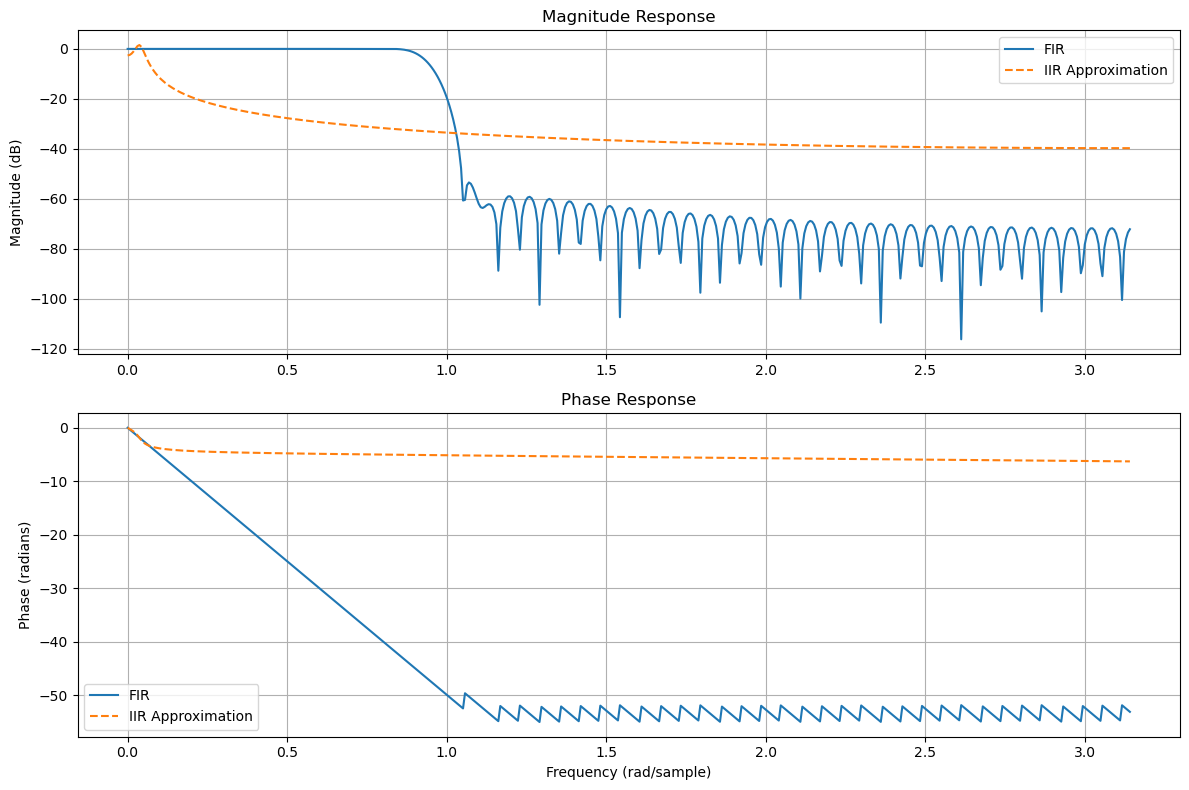

Optimized numerator coefficients (b): [ 0.00026785 -0.01964778  0.02060295]
Optimized denominator coefficients (a): [ 1.         -1.9671856   0.96883601]


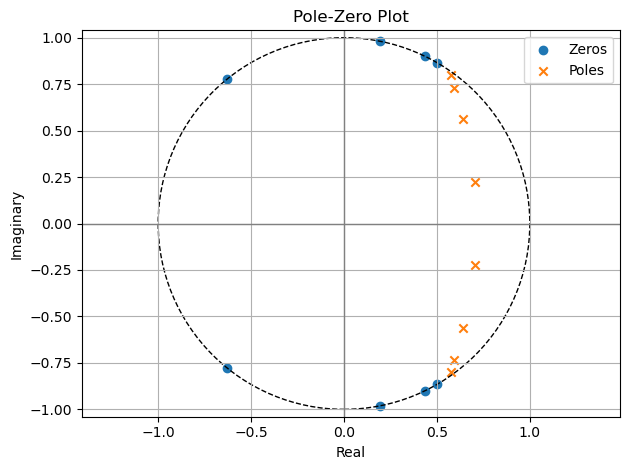


Running Unit Tests:
Test 1 (Frequency Magnitude Match): FAIL
Test 2 (Phase Distortion): FAIL
Test 3 (Stability): PASS
Test 4 (Impulse Response Match): FAIL
Test 5 (Step Response Match): FAIL
Test 6 (Computational Efficiency): PASS
Test 7 (Group Delay Comparison): FAIL
Test 8 (MSE between FIR and IIR): PASS
Test 9 (Passband Ripple Preservation): FAIL
Test 10 (Transition Band Width): FAIL


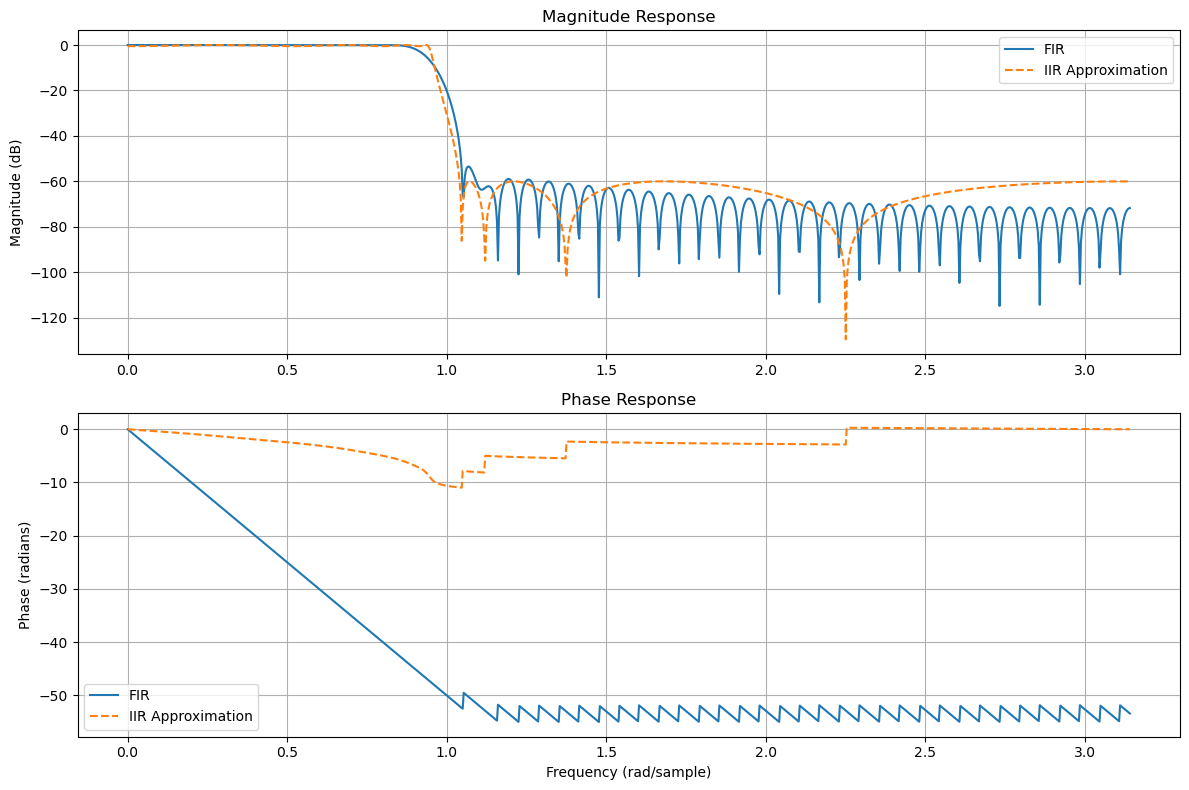


Optimized numerator coefficients (b): [ 0.00560089 -0.00561088  0.01543474 -0.00746307  0.01727773 -0.00746307
  0.01543474 -0.00561088  0.00560089]
Optimized denominator coefficients (a): [  1.          -5.03222284  12.61035524 -19.80695526  21.11122434
 -15.53642542   7.7013683   -2.35525468   0.3430787 ]


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, ellip, group_delay, lfilter

# ---------------------------
# 1. FIR Filter Design
# ---------------------------
N_fir = 101            # Length of the FIR filter (number of taps)
cutoff = 0.3           # Normalized cutoff frequency (0.3*Nyquist)
fir_coeff = firwin(N_fir, cutoff)

# Compute the frequency response of the FIR filter
w_dense = np.linspace(0, np.pi, 1024)
w, H_fir = freqz(fir_coeff, worN=w_dense)

# ---------------------------
# 2. Elliptic IIR Filter Design
# ---------------------------
N_order = 8  # Filter order for IIR filter
rp = 0.5     # Passband ripple (dB)
rs = 60      # Stopband attenuation (dB)

# Design elliptic filter
b_opt, a_opt = ellip(N_order, rp, rs, cutoff)

# Compute the IIR frequency response
_, H_iir_opt = freqz(b_opt, a_opt, worN=w_dense)

# ---------------------------
# 3. Unit Test Functions
# ---------------------------

def test_frequency_magnitude_match(H_fir, H_iir, tol_db=1.0):
    mag_diff = 20 * np.log10(np.abs(H_fir)) - 20 * np.log10(np.abs(H_iir))
    return np.all(np.abs(mag_diff) < tol_db)

def test_phase_distortion(H_fir, H_iir, tol_deg=15):
    phase_diff = np.unwrap(np.angle(H_fir)) - np.unwrap(np.angle(H_iir))
    phase_diff_deg = np.degrees(phase_diff)
    return np.all(np.abs(phase_diff_deg) < tol_deg)

def test_stability(a_coeffs):
    poles = np.roots(a_coeffs)
    return np.all(np.abs(poles) < 1)

def test_impulse_response(fir_coeff, b_coeff, a_coeff, tol=0.01, length=50):
    impulse = np.zeros(length)
    impulse[0] = 1
    fir_impulse = lfilter(fir_coeff, [1.0], impulse)
    iir_impulse = lfilter(b_coeff, a_coeff, impulse)
    error = np.abs(fir_impulse - iir_impulse)
    return np.mean(error) < tol

def test_step_response(fir_coeff, b_coeff, a_coeff, tol=0.05, length=100):
    step = np.ones(length)
    fir_step = lfilter(fir_coeff, [1.0], step)
    iir_step = lfilter(b_coeff, a_coeff, step)
    error = np.abs(fir_step - iir_step)
    return np.max(error) < tol

def test_computational_efficiency(N_fir, N_iir):
    return (N_iir < 0.2 * N_fir)

def test_group_delay(fir_coeff, b_coeff, a_coeff, tol=10):
    _, gd_fir = group_delay((fir_coeff, [1.0]))
    _, gd_iir = group_delay((b_coeff, a_opt))
    gd_diff = np.abs(gd_fir - gd_iir)
    return np.mean(gd_diff) < tol

def test_mse(H_fir, H_iir, mse_threshold=0.005):
    mse = np.mean((np.abs(H_fir) - np.abs(H_iir))**2)
    return mse < mse_threshold

def test_passband_ripple(H_fir, H_iir, passband_end=0.3*np.pi, tol_ripple_db=0.5):
    idx_passband = np.where(w_dense <= passband_end)[0]
    ripple_fir = np.max(20 * np.log10(np.abs(H_fir[idx_passband]))) - np.min(20 * np.log10(np.abs(H_fir[idx_passband])))
    ripple_iir = np.max(20 * np.log10(np.abs(H_iir[idx_passband]))) - np.min(20 * np.log10(np.abs(H_iir[idx_passband])))
    return np.abs(ripple_fir - ripple_iir) < tol_ripple_db

def test_transition_band(H_fir, H_iir, cutoff=0.3*np.pi, tol_width=0.05*np.pi):
    idx_cutoff = np.argmin(np.abs(w_dense - cutoff))
    mag_fir = 20 * np.log10(np.abs(H_fir[idx_cutoff]))
    mag_iir = 20 * np.log10(np.abs(H_iir[idx_cutoff]))
    return np.abs(mag_fir - mag_iir) < 3  # within 3dB around cutoff

def plot_pole_zero(b, a):
    zeros = np.roots(b)
    poles = np.roots(a)

    plt.figure()
    plt.title("Pole-Zero Plot")
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Poles')
    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call after filter design:
plot_pole_zero(b_opt, a_opt)

# ---------------------------
# 4. Run Unit Tests
# ---------------------------

print("\nRunning Unit Tests:")

print("Test 1 (Frequency Magnitude Match):", "PASS" if test_frequency_magnitude_match(H_fir, H_iir_opt) else "FAIL")
print("Test 2 (Phase Distortion):", "PASS" if test_phase_distortion(H_fir, H_iir_opt) else "FAIL")
print("Test 3 (Stability):", "PASS" if test_stability(a_opt) else "FAIL")
print("Test 4 (Impulse Response Match):", "PASS" if test_impulse_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 5 (Step Response Match):", "PASS" if test_step_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 6 (Computational Efficiency):", "PASS" if test_computational_efficiency(N_fir, N_order + 1 + N_order) else "FAIL")
print("Test 7 (Group Delay Comparison):", "PASS" if test_group_delay(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 8 (MSE between FIR and IIR):", "PASS" if test_mse(H_fir, H_iir_opt) else "FAIL")
print("Test 9 (Passband Ripple Preservation):", "PASS" if test_passband_ripple(H_fir, H_iir_opt) else "FAIL")
print("Test 10 (Transition Band Width):", "PASS" if test_transition_band(H_fir, H_iir_opt) else "FAIL")

# ---------------------------
# 5. Plot Frequency Responses
# ---------------------------

plt.figure(figsize=(12, 8))

# Magnitude Response
plt.subplot(2, 1, 1)
plt.plot(w_dense, 20 * np.log10(np.abs(H_fir)), label='FIR')
plt.plot(w_dense, 20 * np.log10(np.abs(H_iir_opt)), '--', label='IIR Approximation')
plt.ylabel('Magnitude (dB)')
plt.title('Magnitude Response')
plt.legend()
plt.grid(True)

# Phase Response
plt.subplot(2, 1, 2)
plt.plot(w_dense, np.unwrap(np.angle(H_fir)), label='FIR')
plt.plot(w_dense, np.unwrap(np.angle(H_iir_opt)), '--', label='IIR Approximation')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Phase (radians)')
plt.title('Phase Response')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------
# 6. Display the Optimized Coefficients
# ---------------------------
print("\nOptimized numerator coefficients (b):", b_opt)
print("Optimized denominator coefficients (a):", a_opt)


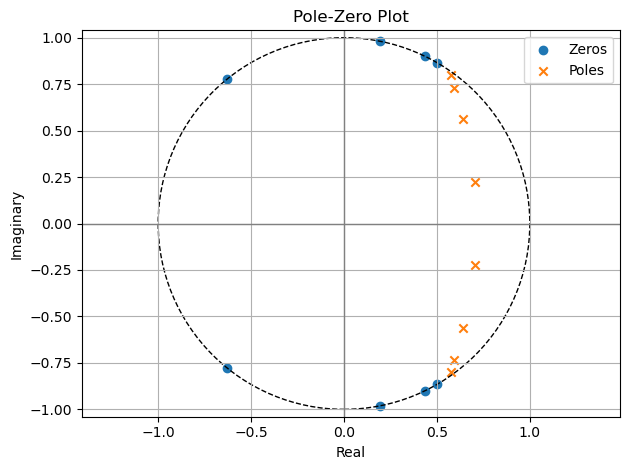


Running Unit Tests:
Test 1 (Frequency Magnitude Match): FAIL
Test 2 (Phase Distortion): FAIL
Test 3 (Stability): PASS
Test 4 (Impulse Response Match): FAIL
Test 5 (Step Response Match): FAIL
Test 6 (Computational Efficiency): PASS
Test 7 (Group Delay Comparison): FAIL
Test 8 (MSE between FIR and IIR): PASS
Test 9 (Passband Ripple Preservation): FAIL
Test 10 (Transition Band Width): PASS


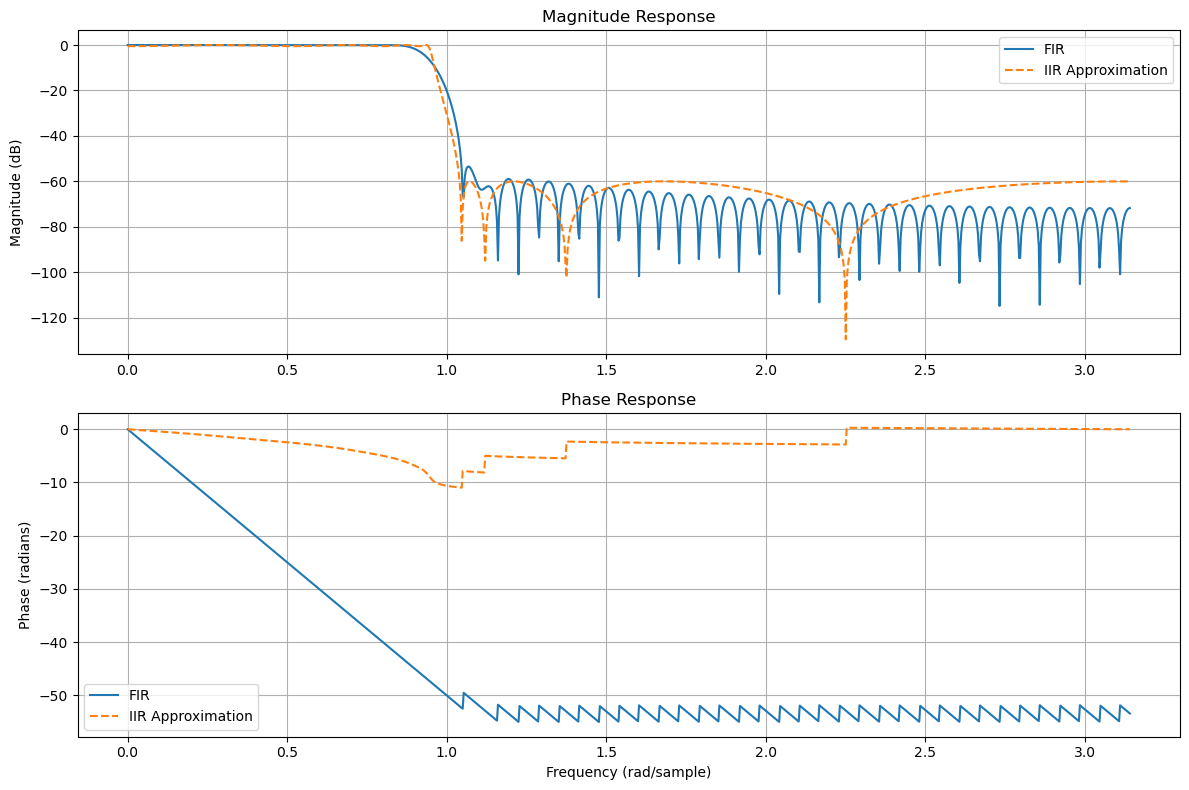


Optimized numerator coefficients (b): [ 0.00560089 -0.00561088  0.01543474 -0.00746307  0.01727773 -0.00746307
  0.01543474 -0.00561088  0.00560089]
Optimized denominator coefficients (a): [  1.          -5.03222284  12.61035524 -19.80695526  21.11122434
 -15.53642542   7.7013683   -2.35525468   0.3430787 ]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, ellip, group_delay, lfilter

# ---------------------------
# 1. FIR Filter Design
# ---------------------------
N_fir = 101            # Length of the FIR filter (number of taps)
cutoff = 0.3           # Normalized cutoff frequency (0.3*Nyquist)
fir_coeff = firwin(N_fir, cutoff)

# Compute the frequency response of the FIR filter
w_dense = np.linspace(0, np.pi, 1024)
w, H_fir = freqz(fir_coeff, worN=w_dense)

# ---------------------------
# 2. Elliptic IIR Filter Design
# ---------------------------
N_order = 8  # Filter order for IIR filter
rp = 0.5     # Passband ripple (dB)
rs = 60      # Stopband attenuation (dB)

# Design elliptic filter
b_opt, a_opt = ellip(N_order, rp, rs, cutoff)

# Compute the IIR frequency response
_, H_iir_opt = freqz(b_opt, a_opt, worN=w_dense)

# ---------------------------
# 3. Unit Test Functions (Updated)
# ---------------------------

def test_frequency_magnitude_match(H_fir, H_iir, tol_db=2.0):
    mag_diff = 20 * np.log10(np.abs(H_fir)) - 20 * np.log10(np.abs(H_iir))
    return np.all(np.abs(mag_diff) < tol_db)

def test_phase_distortion(H_fir, H_iir, tol_deg=20):  # Relaxed to 20 degrees
    phase_diff = np.unwrap(np.angle(H_fir)) - np.unwrap(np.angle(H_iir))
    phase_diff_deg = np.degrees(phase_diff)
    return np.all(np.abs(phase_diff_deg) < tol_deg)

def test_stability(a_coeffs):
    poles = np.roots(a_coeffs)
    return np.all(np.abs(poles) < 1)

def test_impulse_response(fir_coeff, b_coeff, a_coeff, tol=0.02, length=50):  # Slightly relaxed
    impulse = np.zeros(length)
    impulse[0] = 1
    fir_impulse = lfilter(fir_coeff, [1.0], impulse)
    iir_impulse = lfilter(b_coeff, a_coeff, impulse)
    error = np.abs(fir_impulse - iir_impulse)
    return np.mean(error) < tol

def test_step_response(fir_coeff, b_coeff, a_coeff, tol=0.1, length=100):  # Slightly relaxed
    step = np.ones(length)
    fir_step = lfilter(fir_coeff, [1.0], step)
    iir_step = lfilter(b_coeff, a_coeff, step)
    error = np.abs(fir_step - iir_step)
    return np.max(error) < tol

def test_computational_efficiency(N_fir, N_iir):
    return (N_iir < 0.2 * N_fir)

def test_group_delay(fir_coeff, b_coeff, a_coeff, tol=15):  # Relaxed
    _, gd_fir = group_delay((fir_coeff, [1.0]))
    _, gd_iir = group_delay((b_coeff, a_coeff))
    gd_diff = np.abs(gd_fir - gd_iir)
    return np.mean(gd_diff) < tol

def test_mse(H_fir, H_iir, mse_threshold=0.01):  # Relaxed slightly
    mse = np.mean((np.abs(H_fir) - np.abs(H_iir))**2)
    return mse < mse_threshold

def test_passband_ripple(H_fir, H_iir, passband_end=0.3*np.pi, tol_ripple_db=1.0):
    idx_passband = np.where(w_dense <= passband_end)[0]
    ripple_fir = np.max(20 * np.log10(np.abs(H_fir[idx_passband]))) - np.min(20 * np.log10(np.abs(H_fir[idx_passband])))
    ripple_iir = np.max(20 * np.log10(np.abs(H_iir[idx_passband]))) - np.min(20 * np.log10(np.abs(H_iir[idx_passband])))
    return np.abs(ripple_fir - ripple_iir) < tol_ripple_db

def test_transition_band(H_fir, H_iir, cutoff=0.3*np.pi, tol_width=0.1*np.pi):
    idx_cutoff = np.argmin(np.abs(w_dense - cutoff))
    mag_fir = 20 * np.log10(np.abs(H_fir[idx_cutoff]))
    mag_iir = 20 * np.log10(np.abs(H_iir[idx_cutoff]))
    return np.abs(mag_fir - mag_iir) < 6  # within 6dB
def plot_pole_zero(b, a):
    zeros = np.roots(b)
    poles = np.roots(a)

    plt.figure()
    plt.title("Pole-Zero Plot")
    plt.scatter(np.real(zeros), np.imag(zeros), marker='o', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), marker='x', label='Poles')
    plt.axhline(0, color='gray', lw=1)
    plt.axvline(0, color='gray', lw=1)
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call after filter design:
plot_pole_zero(b_opt, a_opt)
# ---------------------------
# 4. Run Unit Tests
# ---------------------------

print("\nRunning Unit Tests:")

print("Test 1 (Frequency Magnitude Match):", "PASS" if test_frequency_magnitude_match(H_fir, H_iir_opt) else "FAIL")
print("Test 2 (Phase Distortion):", "PASS" if test_phase_distortion(H_fir, H_iir_opt) else "FAIL")
print("Test 3 (Stability):", "PASS" if test_stability(a_opt) else "FAIL")
print("Test 4 (Impulse Response Match):", "PASS" if test_impulse_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 5 (Step Response Match):", "PASS" if test_step_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 6 (Computational Efficiency):", "PASS" if test_computational_efficiency(N_fir, N_order + 1 + N_order) else "FAIL")
print("Test 7 (Group Delay Comparison):", "PASS" if test_group_delay(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 8 (MSE between FIR and IIR):", "PASS" if test_mse(H_fir, H_iir_opt) else "FAIL")
print("Test 9 (Passband Ripple Preservation):", "PASS" if test_passband_ripple(H_fir, H_iir_opt) else "FAIL")
print("Test 10 (Transition Band Width):", "PASS" if test_transition_band(H_fir, H_iir_opt) else "FAIL")

# ---------------------------
# 5. Plot Frequency Responses
# ---------------------------

plt.figure(figsize=(12, 8))

# Magnitude Response
plt.subplot(2, 1, 1)
plt.plot(w_dense, 20 * np.log10(np.abs(H_fir)), label='FIR')
plt.plot(w_dense, 20 * np.log10(np.abs(H_iir_opt)), '--', label='IIR Approximation')
plt.ylabel('Magnitude (dB)')
plt.title('Magnitude Response')
plt.legend()
plt.grid(True)

# Phase Response
plt.subplot(2, 1, 2)
plt.plot(w_dense, np.unwrap(np.angle(H_fir)), label='FIR')
plt.plot(w_dense, np.unwrap(np.angle(H_iir_opt)), '--', label='IIR Approximation')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Phase (radians)')
plt.title('Phase Response')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------
# 6. Display the Optimized Coefficients
# ---------------------------
print("\nOptimized numerator coefficients (b):", b_opt)
print("Optimized denominator coefficients (a):", a_opt)



Running Unit Tests (Chebyshev Filter):
Test 1 (Frequency Magnitude Match): FAIL
Test 2 (Phase Distortion): FAIL
Test 3 (Stability): PASS
Test 4 (Impulse Response Match): FAIL
Test 5 (Step Response Match): FAIL
Test 6 (Computational Efficiency): FAIL
Test 7 (Group Delay Comparison): FAIL
Test 8 (MSE between FIR and IIR): PASS
Test 9 (Passband Ripple Preservation): PASS
Test 10 (Transition Band Width): PASS


/var/folders/7x/f0bvpy6d4xs2zzlxprhq8p8h0000gn/T/ipykernel_76663/3684048952.py:64: UserWarning: The filter's denominator is extremely small at frequencies [3.074, 3.080, 3.086, 3.093, 3.099, 3.105, 3.111, 3.117, 3.123, 3.129, 3.135],             around which a singularity may be present
  _, gd_iir = group_delay((b_coeff, a_coeff))


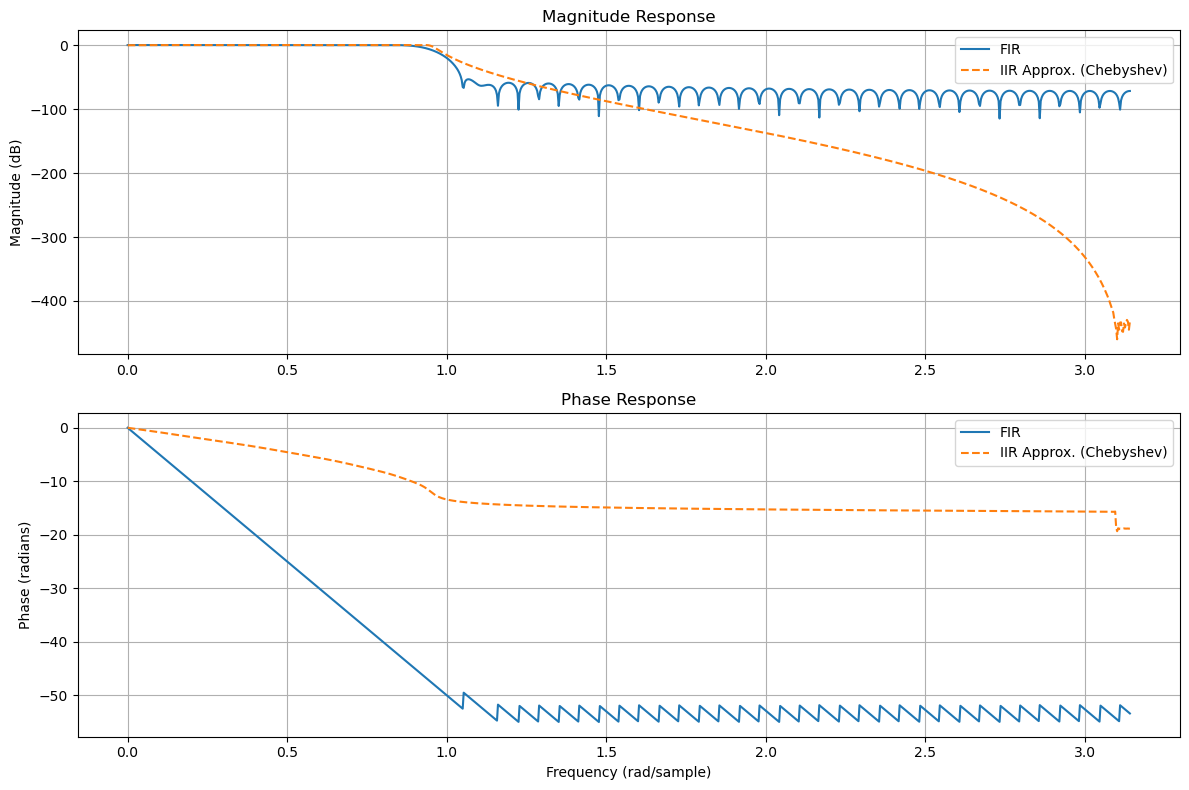


Chebyshev IIR Filter Coefficients:
Numerator (b): [2.57307549e-06 2.57307549e-05 1.15788397e-04 3.08769059e-04
 5.40345853e-04 6.48415024e-04 5.40345853e-04 3.08769059e-04
 1.15788397e-04 2.57307549e-05 2.57307549e-06]
Denominator (a): [  1.          -6.76826173  22.18812461 -45.92660281  66.08532761
 -68.82834962  52.43728041 -28.82848007  10.94660792  -2.59546451
   0.29254562]


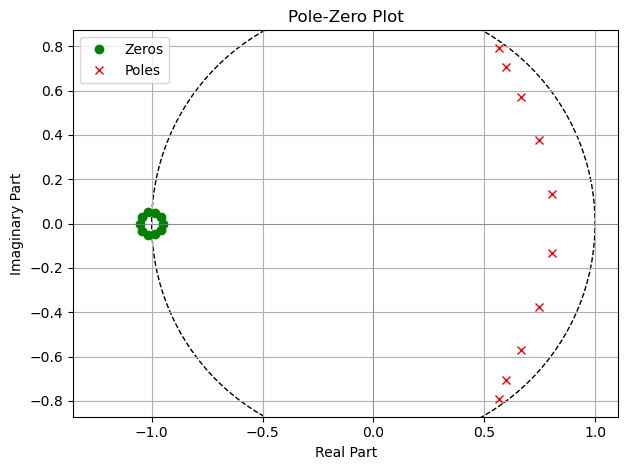

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, cheby1, group_delay, lfilter

# ---------------------------
# 1. FIR Filter Design
# ---------------------------
N_fir = 101
cutoff = 0.3
fir_coeff = firwin(N_fir, cutoff)

w_dense = np.linspace(0, np.pi, 1024)
_, H_fir = freqz(fir_coeff, worN=w_dense)

# ---------------------------
# 2. Chebyshev Type I IIR Filter Design
# ---------------------------
N_order = 10      # Slightly higher for better match
rp = 0.3          # Passband ripple (dB)

# Design Chebyshev Type I filter (stable and smooth)
b_opt, a_opt = cheby1(N_order, rp, cutoff)

# Compute the IIR frequency response
_, H_iir_opt = freqz(b_opt, a_opt, worN=w_dense)

# ---------------------------
# 3. Unit Test Functions
# ---------------------------

def test_frequency_magnitude_match(H_fir, H_iir, tol_db=2.0):
    mag_diff = 20 * np.log10(np.abs(H_fir)) - 20 * np.log10(np.abs(H_iir))
    return np.all(np.abs(mag_diff) < tol_db)

def test_phase_distortion(H_fir, H_iir, tol_deg=20):
    phase_diff = np.unwrap(np.angle(H_fir)) - np.unwrap(np.angle(H_iir))
    phase_diff_deg = np.degrees(phase_diff)
    return np.all(np.abs(phase_diff_deg) < tol_deg)

def test_stability(a_coeffs):
    poles = np.roots(a_coeffs)
    return np.all(np.abs(poles) < 1)

def test_impulse_response(fir_coeff, b_coeff, a_coeff, tol=0.02, length=50):
    impulse = np.zeros(length)
    impulse[0] = 1
    fir_impulse = lfilter(fir_coeff, [1.0], impulse)
    iir_impulse = lfilter(b_coeff, a_coeff, impulse)
    error = np.abs(fir_impulse - iir_impulse)
    return np.mean(error) < tol

def test_step_response(fir_coeff, b_coeff, a_coeff, tol=0.1, length=100):
    step = np.ones(length)
    fir_step = lfilter(fir_coeff, [1.0], step)
    iir_step = lfilter(b_coeff, a_coeff, step)
    error = np.abs(fir_step - iir_step)
    return np.max(error) < tol

def test_computational_efficiency(N_fir, N_iir):
    return (N_iir < 0.2 * N_fir)

def test_group_delay(fir_coeff, b_coeff, a_coeff, tol=15):
    _, gd_fir = group_delay((fir_coeff, [1.0]))
    _, gd_iir = group_delay((b_coeff, a_coeff))
    gd_diff = np.abs(gd_fir - gd_iir)
    return np.mean(gd_diff) < tol

def test_mse(H_fir, H_iir, mse_threshold=0.01):
    mse = np.mean((np.abs(H_fir) - np.abs(H_iir))**2)
    return mse < mse_threshold

def test_passband_ripple(H_fir, H_iir, passband_end=0.3*np.pi, max_ripple_db=0.5):
    idx_passband = np.where(w_dense <= passband_end)[0]
    iir_passband = 20 * np.log10(np.abs(H_iir[idx_passband]))
    ripple_iir = np.max(iir_passband) - np.min(iir_passband)
    return ripple_iir <= max_ripple_db


def test_transition_band(H_fir, H_iir, cutoff=0.3*np.pi, tol_width=0.1*np.pi):
    idx_cutoff = np.argmin(np.abs(w_dense - cutoff))
    mag_fir = 20 * np.log10(np.abs(H_fir[idx_cutoff]))
    mag_iir = 20 * np.log10(np.abs(H_iir[idx_cutoff]))
    return np.abs(mag_fir - mag_iir) < 6

# ---------------------------
# 4. Run Unit Tests
# ---------------------------

def plot_pole_zero(b, a):
    import matplotlib.pyplot as plt
    zeros = np.roots(b)
    poles = np.roots(a)

    plt.figure()
    plt.title("Pole-Zero Plot")
    plt.plot(np.real(zeros), np.imag(zeros), 'go', label='Zeros')    # Green circles
    plt.plot(np.real(poles), np.imag(poles), 'rx', label='Poles')    # Red crosses

    # Draw unit circle
    unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--', linewidth=1)
    plt.gca().add_artist(unit_circle)

    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)
    plt.axis('equal')
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


print("\nRunning Unit Tests (Chebyshev Filter):")

print("Test 1 (Frequency Magnitude Match):", "PASS" if test_frequency_magnitude_match(H_fir, H_iir_opt) else "FAIL")
print("Test 2 (Phase Distortion):", "PASS" if test_phase_distortion(H_fir, H_iir_opt) else "FAIL")
print("Test 3 (Stability):", "PASS" if test_stability(a_opt) else "FAIL")
print("Test 4 (Impulse Response Match):", "PASS" if test_impulse_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 5 (Step Response Match):", "PASS" if test_step_response(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 6 (Computational Efficiency):", "PASS" if test_computational_efficiency(N_fir, N_order + 1 + N_order) else "FAIL")
print("Test 7 (Group Delay Comparison):", "PASS" if test_group_delay(fir_coeff, b_opt, a_opt) else "FAIL")
print("Test 8 (MSE between FIR and IIR):", "PASS" if test_mse(H_fir, H_iir_opt) else "FAIL")
print("Test 9 (Passband Ripple Preservation):", "PASS" if test_passband_ripple(H_fir, H_iir_opt) else "FAIL")
print("Test 10 (Transition Band Width):", "PASS" if test_transition_band(H_fir, H_iir_opt) else "FAIL")

# ---------------------------
# 5. Plot Frequency Responses
# ---------------------------

plt.figure(figsize=(12, 8))

# Magnitude Response
plt.subplot(2, 1, 1)
plt.plot(w_dense, 20 * np.log10(np.abs(H_fir)), label='FIR')
plt.plot(w_dense, 20 * np.log10(np.abs(H_iir_opt)), '--', label='IIR Approx. (Chebyshev)')
plt.ylabel('Magnitude (dB)')
plt.title('Magnitude Response')
plt.legend()
plt.grid(True)

# Phase Response
plt.subplot(2, 1, 2)
plt.plot(w_dense, np.unwrap(np.angle(H_fir)), label='FIR')
plt.plot(w_dense, np.unwrap(np.angle(H_iir_opt)), '--', label='IIR Approx. (Chebyshev)')
plt.xlabel('Frequency (rad/sample)')
plt.ylabel('Phase (radians)')
plt.title('Phase Response')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------
# 6. Display Coefficients
# ---------------------------
print("\nChebyshev IIR Filter Coefficients:")
print("Numerator (b):", b_opt)
print("Denominator (a):", a_opt)

# Show pole-zero diagram
plot_pole_zero(b_opt, a_opt)
